### Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../data/processed/traffic_volume_cleaned.csv')
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,date_time,traffic_volume,hour,day_of_week,month,hour_sin,hour_cos,month_sin,month_cos
0,Not Holiday,288.28,0.0,0.0,40,Clouds,2012-10-02 09:00:00,5545,9,Tuesday,10,7.071068e-01,-0.707107,-0.866025,0.5
1,Not Holiday,289.36,0.0,0.0,75,Clouds,2012-10-02 10:00:00,4516,10,Tuesday,10,5.000000e-01,-0.866025,-0.866025,0.5
2,Not Holiday,289.58,0.0,0.0,90,Clouds,2012-10-02 11:00:00,4767,11,Tuesday,10,2.588190e-01,-0.965926,-0.866025,0.5
3,Not Holiday,290.13,0.0,0.0,90,Clouds,2012-10-02 12:00:00,5026,12,Tuesday,10,1.224647e-16,-1.000000,-0.866025,0.5
4,Not Holiday,291.14,0.0,0.0,75,Clouds,2012-10-02 13:00:00,4918,13,Tuesday,10,-2.588190e-01,-0.965926,-0.866025,0.5


### Convert date_time & Sort Chronologically

In [3]:
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

### Define Features (X) and Target (y)

In [4]:
X = df.drop(columns=["traffic_volume", "date_time", "hour", "month"])
y = df["traffic_volume"]

X.columns.tolist()

['holiday',
 'temp',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'weather_main',
 'day_of_week',
 'hour_sin',
 'hour_cos',
 'month_sin',
 'month_cos']

### Chronological Train/Test Split

In [5]:
split_index = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 32451
Testing samples: 8113


### Preprocessing Pipeline (Scaling + OHE)

In [6]:
categorical_features = ["holiday", "weather_main", "day_of_week"]

numerical_features = [
    "temp", "rain_1h", "snow_1h", "clouds_all",
    "hour_sin", "hour_cos", "month_sin", "month_cos"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

### Define Models

In [7]:
models = {
    "Linear Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1))
    ])
}

### Train & Evaluate All Models

In [8]:
results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

c:\Users\Abdo\anaconda3\envs\ai_env\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Abdo\anaconda3\envs\ai_env\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Abdo\anaconda3\envs\ai_env\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,MAE,RMSE,R2
0,XGBoost,234.068680,379.521512,0.962894
1,Random Forest,250.915203,411.267859,0.956427
2,Linear Regression,821.574272,1042.941622,0.719787


### Visualize Model Comparison

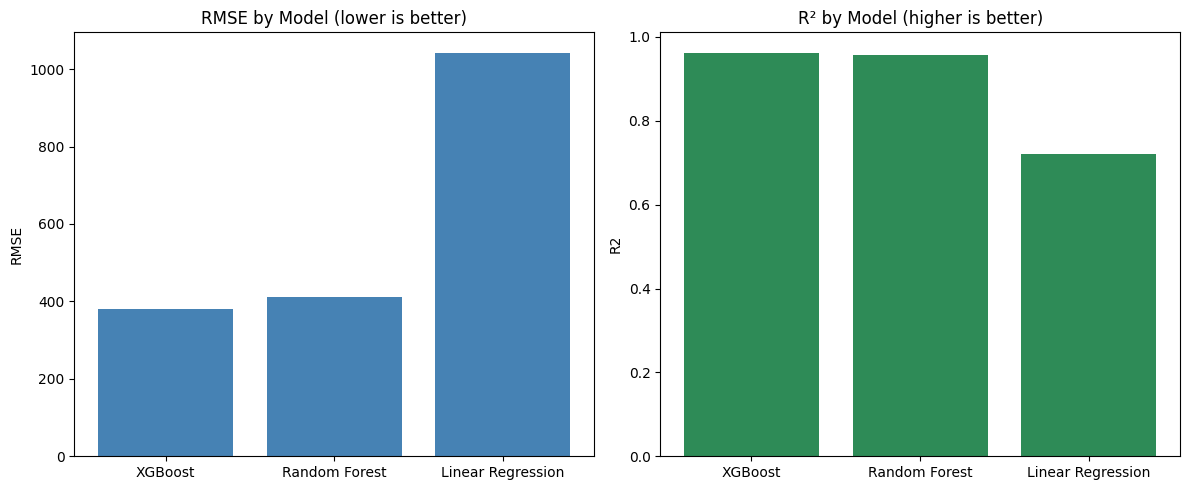

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results_df["Model"], results_df["RMSE"], color="steelblue")
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].set_ylabel("RMSE")

axes[1].bar(results_df["Model"], results_df["R2"], color="seagreen")
axes[1].set_title("R² by Model (higher is better)")
axes[1].set_ylabel("R2")

plt.tight_layout()
plt.show()

### Select Best Model

In [10]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"Best performing model: {best_model_name}")
results_df

Best performing model: XGBoost


,Model,MAE,RMSE,R2
0,XGBoost,234.068680,379.521512,0.962894
1,Random Forest,250.915203,411.267859,0.956427
2,Linear Regression,821.574272,1042.941622,0.719787


### Train vs Test Performance (Overfitting Check)

In [11]:
best_pipeline = models[best_model_name]

y_train_pred = best_pipeline.predict(X_train)
y_test_pred = best_pipeline.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Train R²: {train_r2:.4f}   |   Test R²: {test_r2:.4f}")
print(f"Train MAE: {train_mae:.2f}   |   Test MAE: {test_mae:.2f}")

Train R²: 0.9689   |   Test R²: 0.9629
Train MAE: 219.55   |   Test MAE: 234.07


c:\Users\Abdo\anaconda3\envs\ai_env\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [12]:
## 11. Save Production Artifacts

from pathlib import Path
import json
import sys

import joblib

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

from src.utils.helpers import Helpers

artifact_dir = project_root / "src" / "models"
artifact_dir.mkdir(parents=True, exist_ok=True)

scaler = preprocessor.named_transformers_["num"]
encoder = preprocessor.named_transformers_["cat"]

joblib.dump(scaler, artifact_dir / "traffic_volume_scaler.joblib")
joblib.dump(encoder, artifact_dir / "traffic_volume_encoder.joblib")
joblib.dump(best_model, artifact_dir / "traffic_volume_model_pipeline.joblib")

artifact_metadata = {
    "model_name": best_model_name,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "scaler_path": str(artifact_dir / "traffic_volume_scaler.joblib"),
    "encoder_path": str(artifact_dir / "traffic_volume_encoder.joblib"),
    "pipeline_path": str(artifact_dir / "traffic_volume_model_pipeline.joblib"),
}

(artifact_dir / "traffic_volume_model_metadata.json").write_text(
    json.dumps(artifact_metadata, indent=2),
    encoding="utf-8",
)

print("Artifacts saved to:", artifact_dir)
print("Scaler:", artifact_dir / "traffic_volume_scaler.joblib")
print("Encoder:", artifact_dir / "traffic_volume_encoder.joblib")
print("Pipeline:", artifact_dir / "traffic_volume_model_pipeline.joblib")
print("Metadata:", artifact_dir / "traffic_volume_model_metadata.json")

Artifacts saved to: D:\SIC\Traffic Volume\src\models
Scaler: D:\SIC\Traffic Volume\src\models\traffic_volume_scaler.joblib
Encoder: D:\SIC\Traffic Volume\src\models\traffic_volume_encoder.joblib
Pipeline: D:\SIC\Traffic Volume\src\models\traffic_volume_model_pipeline.joblib
Metadata: D:\SIC\Traffic Volume\src\models\traffic_volume_model_metadata.json


### Save Best Model to `src/models/`

In [13]:
import joblib
import json
from pathlib import Path

MODEL_DIR = Path("../src/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save the full pipeline (preprocessor + model)
pipeline_path = MODEL_DIR / "traffic_volume_model_pipeline.joblib"
joblib.dump(best_model, pipeline_path)

# Save metadata aligned with this notebook
metadata = {
    "model_name": best_model_name,
    "numerical_features": ["temp", "rain_1h", "snow_1h", "clouds_all",
                            "hour_sin", "hour_cos", "month_sin", "month_cos"],
    "categorical_features": ["holiday", "weather_main", "day_of_week"],
    "pipeline_path": str(pipeline_path),
    "train_r2": round(float(r2_score(y_train, best_model.predict(X_train))), 4),
    "test_r2": round(float(r2_score(y_test, best_model.predict(X_test))), 4),
    "test_mae": round(float(mean_absolute_error(y_test, best_model.predict(X_test))), 2),
    "test_rmse": round(float(results_df.iloc[0]["RMSE"]), 2),
}

metadata_path = MODEL_DIR / "traffic_volume_model_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"✅ Pipeline saved  : {pipeline_path}")
print(f"✅ Metadata saved  : {metadata_path}")
print(f"   Model          : {best_model_name}")
print(f"   Test R²        : {metadata['test_r2']}")
print(f"   Test MAE       : {metadata['test_mae']}")


c:\Users\Abdo\anaconda3\envs\ai_env\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Abdo\anaconda3\envs\ai_env\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✅ Pipeline saved  : ..\src\models\traffic_volume_model_pipeline.joblib
✅ Metadata saved  : ..\src\models\traffic_volume_model_metadata.json
   Model          : XGBoost
   Test R²        : 0.9629
   Test MAE       : 234.07
